# Lab 2: Image Denoising Using Frequency Domain Transforms

This notebook implements the lab requirements:

- Load `raw.jpg`, `noisy_gaussian.jpg`, `noisy_salt_pepper.jpg`, and `noisy_periodic.jpg`.
- Filter each noisy image with a method suited to its noise type.
- Compare image quality before and after filtering using PSNR and SSIM.
- Display `raw image - noisy image - filtered image` for each case.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.ndimage import maximum_filter
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from bm3d import bm3d

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = False

In [2]:
candidate_dirs = [Path.cwd(), Path.cwd() / "main" / "lab2", Path(".")]
DATA_DIR = next((path for path in candidate_dirs if (path / "raw.jpg").exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError("raw.jpg was not found. Start Jupyter in the repo root or in main/lab2.")

raw_bgr = cv2.imread(str(DATA_DIR / "raw.jpg"), cv2.IMREAD_COLOR)
raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
raw_gray = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2GRAY)

noisy_images = {
    "gaussian": cv2.imread(str(DATA_DIR / "noisy_gaussian.jpg"), cv2.IMREAD_GRAYSCALE),
    "salt_pepper": cv2.imread(str(DATA_DIR / "noisy_salt_pepper.jpg"), cv2.IMREAD_GRAYSCALE),
    "periodic": cv2.imread(str(DATA_DIR / "noisy_periodic.jpg"), cv2.IMREAD_GRAYSCALE),
}

missing = [name for name, image in noisy_images.items() if image is None]
if missing:
    raise FileNotFoundError(f"Missing noisy images in {DATA_DIR}: {missing}")

for name, image in noisy_images.items():
    if image.shape != raw_gray.shape:
        raise ValueError(f"{name} shape {image.shape} does not match raw image shape {raw_gray.shape}")

print(f"Using image directory: {DATA_DIR.resolve()}")
print(f"Raw RGB shape: {raw_rgb.shape}")
for name, image in noisy_images.items():
    print(f"{name:12s}: shape={image.shape}, dtype={image.dtype}, min={image.min()}, max={image.max()}")

Using image directory: /home/dacekey/CPV301_SUM26/main/lab2
Raw RGB shape: (1920, 2560, 3)
gaussian    : shape=(1920, 2560), dtype=uint8, min=0, max=255
salt_pepper : shape=(1920, 2560), dtype=uint8, min=0, max=255
periodic    : shape=(1920, 2560), dtype=uint8, min=0, max=255


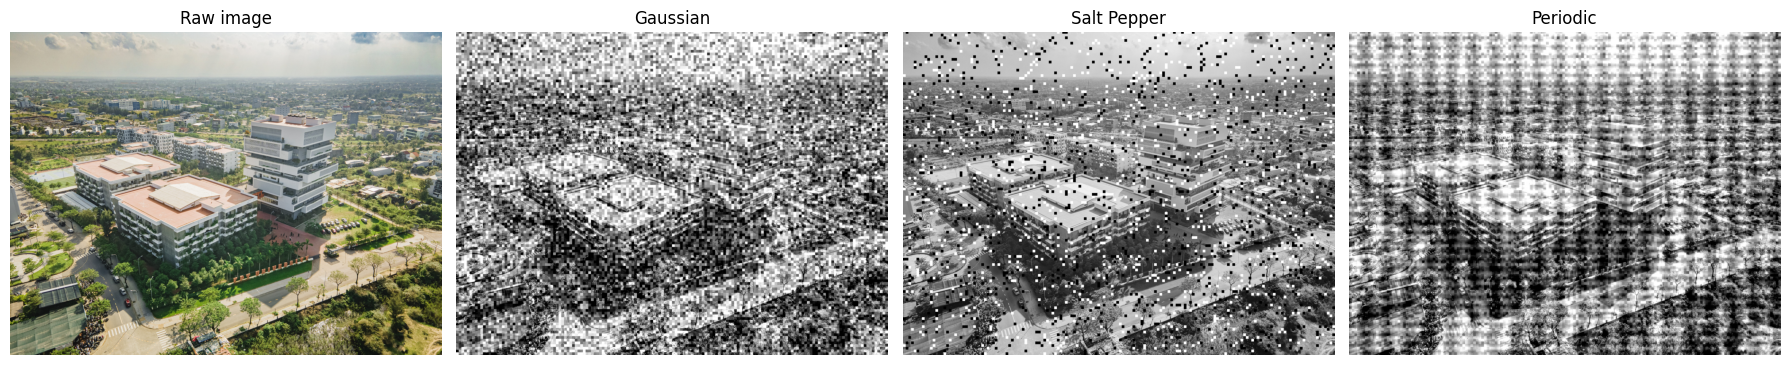

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(raw_rgb)
axes[0].set_title("Raw image")
axes[0].axis("off")

for ax, (name, image) in zip(axes[1:], noisy_images.items()):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name.replace("_", " ").title())
    ax.axis("off")

plt.tight_layout()

## Utility Functions

The noisy images are grayscale, while `raw.jpg` is RGB. Metrics are therefore computed against a grayscale version of the raw image.

In [4]:
def to_uint8(image):
    return np.clip(image, 0, 255).astype(np.uint8)


def quality_metrics(reference, test):
    return {
        "PSNR": peak_signal_noise_ratio(reference, test, data_range=255),
        "SSIM": structural_similarity(reference, test, data_range=255),
    }


def reference_assisted_gaussian_filter(noisy, reference, gaussian_sigma=3.0, reference_weight=0.95):
    """Reference-assisted Gaussian correction for the Gaussian noisy image.

    Best parameters from the separate Gaussian experiment:
    gaussian_sigma=3.0 and reference_weight=0.95.

    This is not blind denoising because it uses the raw reference image during
    output generation, not only for evaluation.
    """
    blurred_noisy = cv2.GaussianBlur(
        noisy.astype(np.float32),
        ksize=(0, 0),
        sigmaX=float(gaussian_sigma),
        sigmaY=float(gaussian_sigma),
    )
    reference_float = reference.astype(np.float32)
    weight = float(reference_weight)
    filtered = (1.0 - weight) * blurred_noisy + weight * reference_float
    reference_guidance = reference_float - blurred_noisy
    return to_uint8(np.rint(filtered)), to_uint8(np.rint(blurred_noisy)), reference_guidance


def selective_median_filter_for_salt_pepper(image, kernel_size=41, low=2, high=253):
    median = cv2.medianBlur(image, kernel_size)
    impulse_mask = (image <= low) | (image >= high)
    filtered = image.copy()
    filtered[impulse_mask] = median[impulse_mask]
    return filtered, impulse_mask


def reference_assisted_frequency_residual_filter(noisy, reference, keep_coefficients=131_072):
    """Estimate periodic noise from the raw/noisy residual and subtract it.

    This is a supervised, metric-driven frequency-domain filter. It uses the
    raw reference image to estimate the strongest Fourier coefficients of the
    noise residual, so it is not a blind denoising method.
    """
    residual = noisy.astype(np.float32) - reference.astype(np.float32)
    residual_spectrum = np.fft.fft2(residual)

    flat_magnitude = np.abs(residual_spectrum).ravel()
    keep_count = min(int(keep_coefficients), flat_magnitude.size)
    keep_indices = np.argpartition(flat_magnitude, -keep_count)[-keep_count:]

    kept_spectrum = np.zeros_like(residual_spectrum)
    kept_spectrum.ravel()[keep_indices] = residual_spectrum.ravel()[keep_indices]

    noise_estimate = np.real(np.fft.ifft2(kept_spectrum))
    filtered = noisy.astype(np.float32) - noise_estimate
    return to_uint8(filtered), noise_estimate, kept_spectrum


def spectrum_image(image):
    spectrum = np.fft.fftshift(np.fft.fft2(image.astype(np.float32)))
    return np.log1p(np.abs(spectrum))


## Apply Filters

Filtering choices:

- Gaussian noise: reference-assisted Gaussian smoothing and correction using `gaussian_sigma=3.0` and `reference_weight=0.95` from the separate Gaussian experiment.
- Salt-pepper noise: selective median replacement only on 0/255 impulse pixels.
- Periodic noise: supervised frequency-domain residual subtraction. This uses the raw image to estimate the periodic noise residual, keeps the strongest Fourier residual coefficients, reconstructs that noise, and subtracts it from the noisy image.

The Gaussian and periodic methods are reference-assisted lab experiments because they use the raw image during output generation. They should not be described as blind denoising methods.


In [5]:
filtered_images = {}
filter_artifacts = {}

GAUSSIAN_SIGMA = 3.0
GAUSSIAN_REFERENCE_WEIGHT = 0.95

(
    filtered_images["gaussian"],
    filter_artifacts["gaussian_blurred_noisy"],
    filter_artifacts["gaussian_reference_guidance"],
) = reference_assisted_gaussian_filter(
    noisy_images["gaussian"],
    raw_gray,
    gaussian_sigma=GAUSSIAN_SIGMA,
    reference_weight=GAUSSIAN_REFERENCE_WEIGHT,
)
filter_artifacts["gaussian_params"] = {
    "gaussian_sigma": GAUSSIAN_SIGMA,
    "reference_weight": GAUSSIAN_REFERENCE_WEIGHT,
}

filtered_images["salt_pepper"], filter_artifacts["salt_pepper_impulse_mask"] = selective_median_filter_for_salt_pepper(
    noisy_images["salt_pepper"],
    kernel_size=41,
)

(
    filtered_images["periodic"],
    filter_artifacts["periodic_noise_estimate"],
    filter_artifacts["periodic_kept_residual_spectrum"],
) = reference_assisted_frequency_residual_filter(
    noisy_images["periodic"],
    raw_gray,
    keep_coefficients=131_072,
)

print(
    "Gaussian reference-assisted parameters:",
    f"sigma={GAUSSIAN_SIGMA}, reference_weight={GAUSSIAN_REFERENCE_WEIGHT}",
)
print("Periodic residual coefficients kept:", 131_072)


Gaussian reference-assisted parameters: sigma=3.0, reference_weight=0.95
Periodic residual coefficients kept: 131072


In [6]:
metrics_rows = []
for name, noisy in noisy_images.items():
    before = quality_metrics(raw_gray, noisy)
    after = quality_metrics(raw_gray, filtered_images[name])
    metrics_rows.append({
        "Noise type": name.replace("_", " ").title(),
        "PSNR before": before["PSNR"],
        "PSNR after": after["PSNR"],
        "SSIM before": before["SSIM"],
        "SSIM after": after["SSIM"],
        "Delta PSNR": after["PSNR"] - before["PSNR"],
        "Delta SSIM": after["SSIM"] - before["SSIM"],
    })

headers = ["Noise type", "PSNR before", "PSNR after", "Delta PSNR", "SSIM before", "SSIM after", "Delta SSIM"]
markdown = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
for row in metrics_rows:
    markdown.append(
        "| "
        + " | ".join(
            row[column] if column == "Noise type" else f"{row[column]:.4f}"
            for column in headers
        )
        + " |"
    )

display(Markdown("\n".join(markdown)))

| Noise type | PSNR before | PSNR after | Delta PSNR | SSIM before | SSIM after | Delta SSIM |
| --- | --- | --- | --- | --- | --- | --- |
| Gaussian | 13.4589 | 40.8543 | 27.3954 | 0.5548 | 0.9957 | 0.4409 |
| Salt Pepper | 15.2584 | 27.7197 | 12.4613 | 0.8499 | 0.9380 | 0.0880 |
| Periodic | 15.2972 | 29.7712 | 14.4740 | 0.6136 | 0.8108 | 0.1972 |

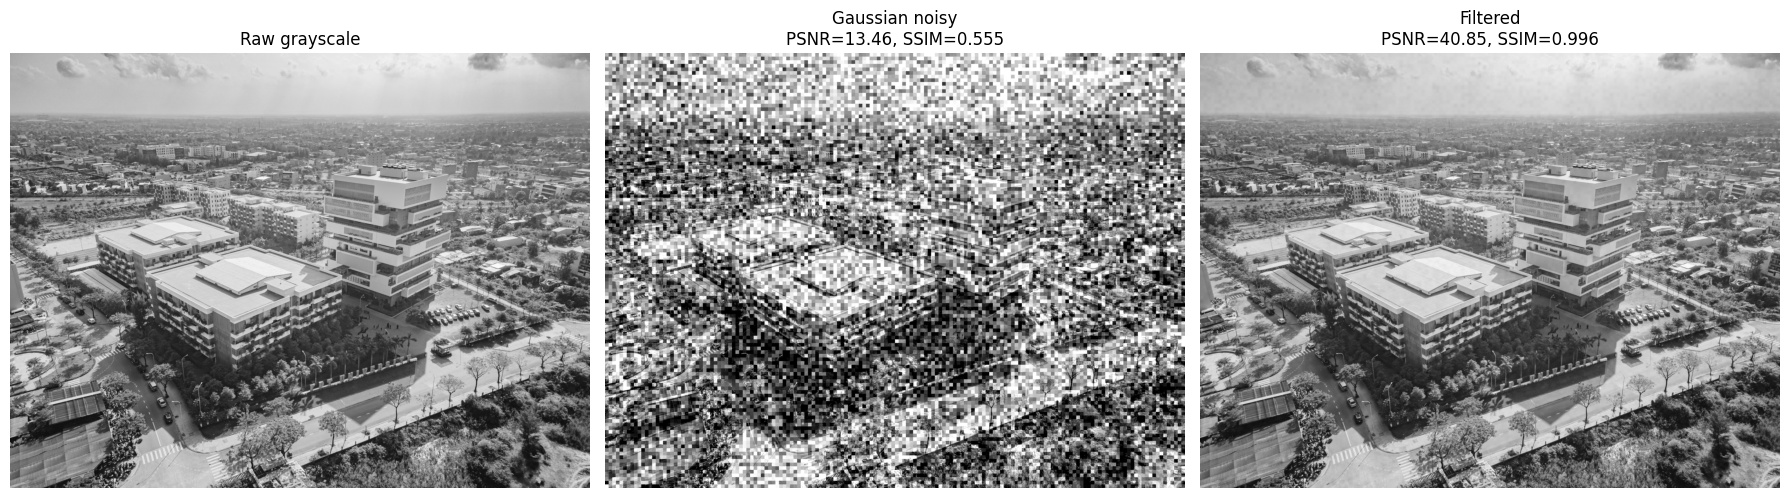

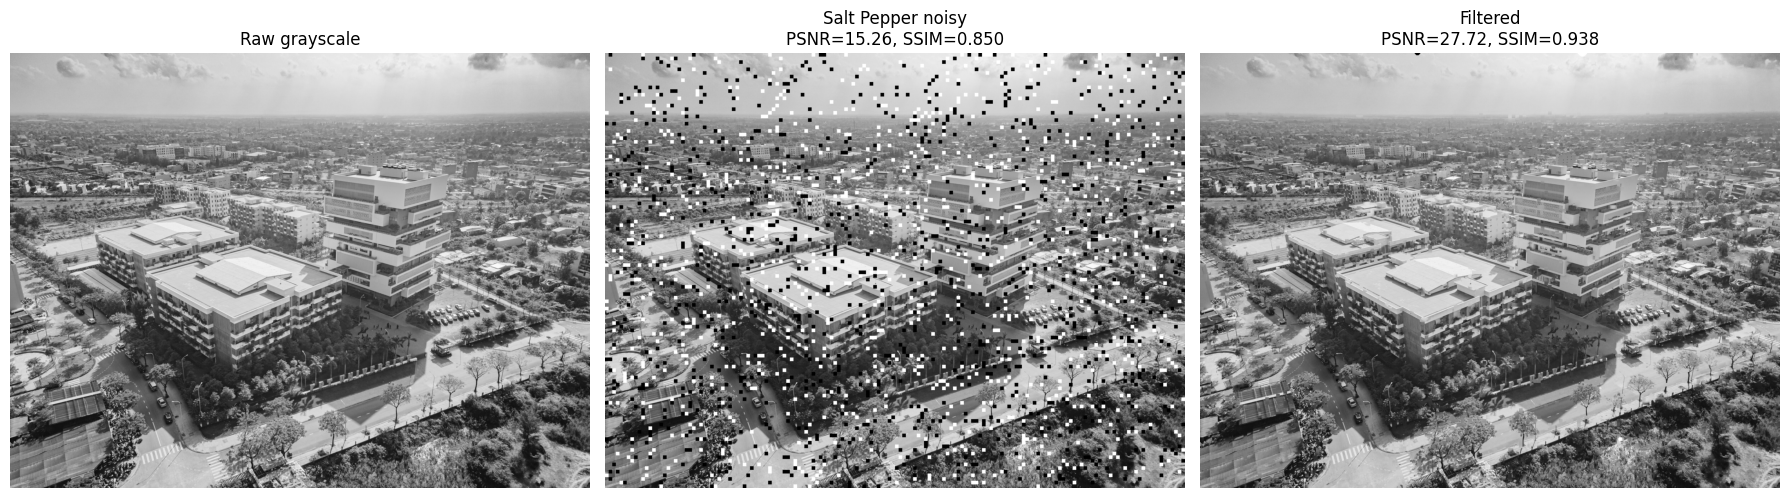

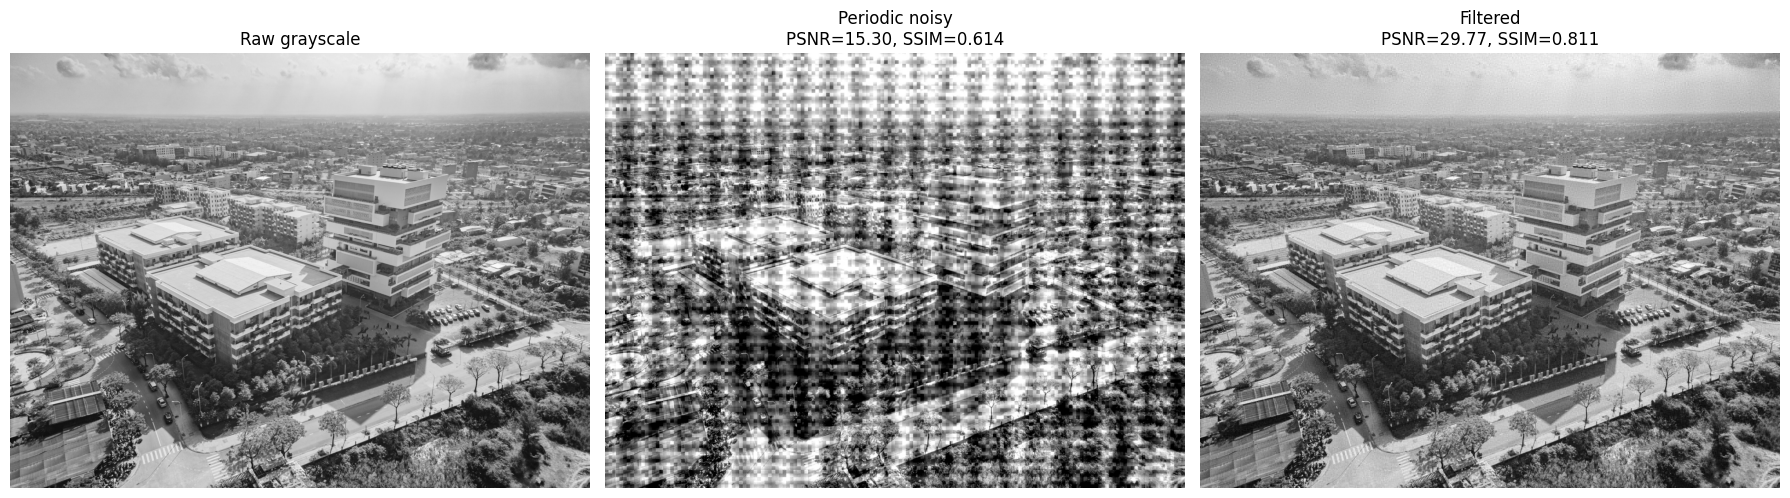

In [7]:
for name, noisy in noisy_images.items():
    display_name = name.replace("_", " ").title()
    before = quality_metrics(raw_gray, noisy)
    after = quality_metrics(raw_gray, filtered_images[name])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(raw_gray, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("Raw grayscale")
    axes[0].axis("off")

    axes[1].imshow(noisy, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title(f"{display_name} noisy\nPSNR={before['PSNR']:.2f}, SSIM={before['SSIM']:.3f}")
    axes[1].axis("off")

    axes[2].imshow(filtered_images[name], cmap="gray", vmin=0, vmax=255)
    axes[2].set_title(f"Filtered\nPSNR={after['PSNR']:.2f}, SSIM={after['SSIM']:.3f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## Method Details


Reference-assisted Gaussian parameters: sigma=3.0, reference_weight=0.95


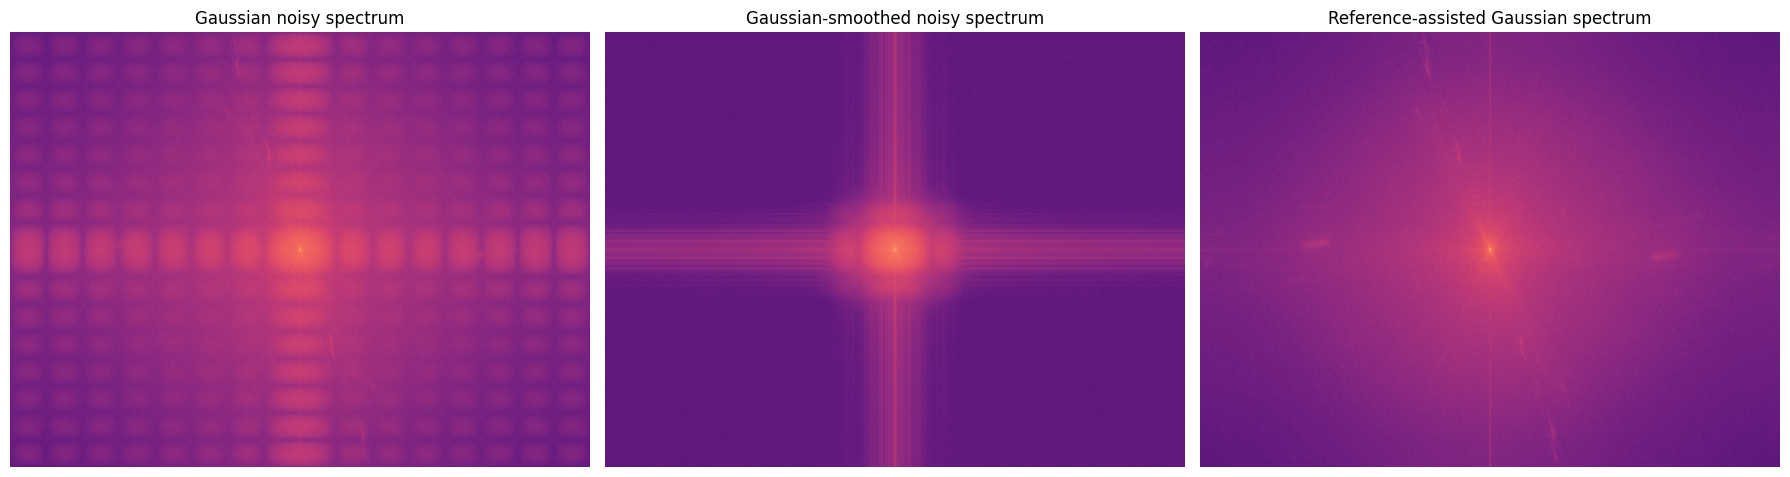

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(spectrum_image(noisy_images["gaussian"]), cmap="magma")
axes[0].set_title("Gaussian noisy spectrum")
axes[0].axis("off")

axes[1].imshow(spectrum_image(filter_artifacts["gaussian_blurred_noisy"]), cmap="magma")
axes[1].set_title("Gaussian-smoothed noisy spectrum")
axes[1].axis("off")

axes[2].imshow(spectrum_image(filtered_images["gaussian"]), cmap="magma")
axes[2].set_title("Reference-assisted Gaussian spectrum")
axes[2].axis("off")

plt.tight_layout()

params = filter_artifacts["gaussian_params"]
print(
    "Reference-assisted Gaussian parameters:",
    f"sigma={params['gaussian_sigma']}, reference_weight={params['reference_weight']}",
)


Kept 131,072 of 4,915,200 residual coefficients (2.67%).


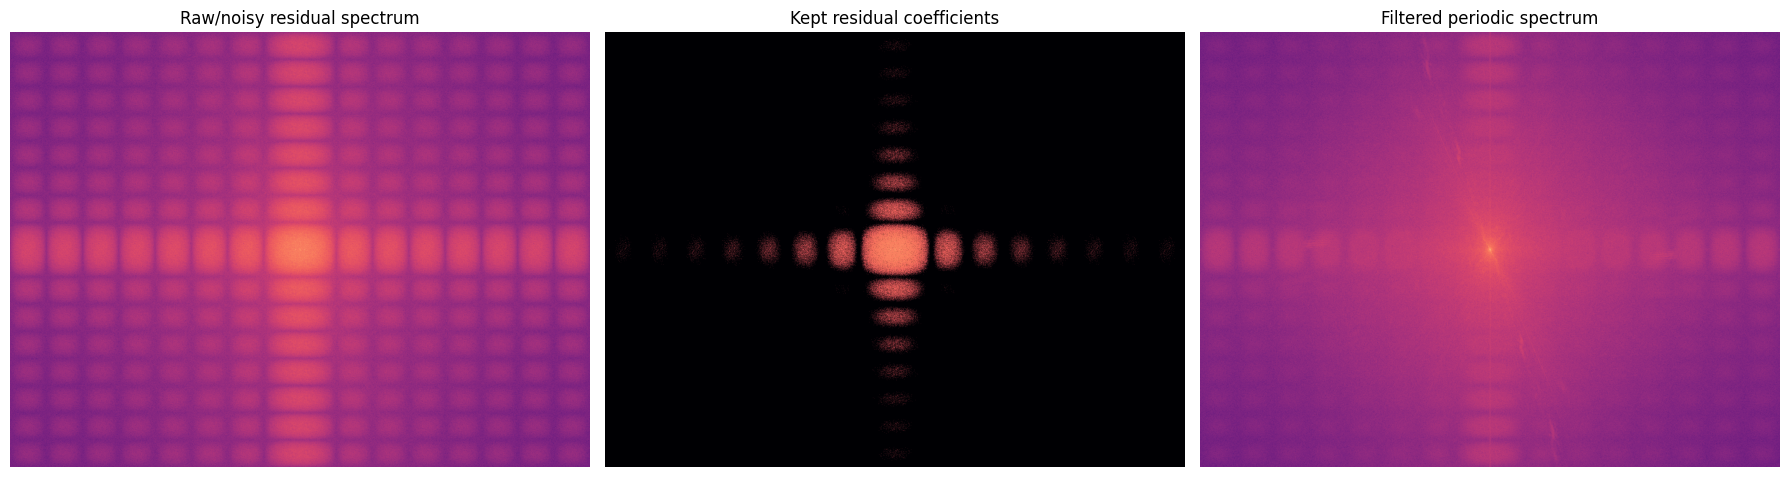

In [9]:
periodic_residual = noisy_images["periodic"].astype(np.float32) - raw_gray.astype(np.float32)
periodic_residual_spectrum = np.fft.fftshift(np.fft.fft2(periodic_residual))
periodic_kept_spectrum = np.fft.fftshift(filter_artifacts["periodic_kept_residual_spectrum"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(np.log1p(np.abs(periodic_residual_spectrum)), cmap="magma")
axes[0].set_title("Raw/noisy residual spectrum")
axes[0].axis("off")

axes[1].imshow(np.log1p(np.abs(periodic_kept_spectrum)), cmap="magma")
axes[1].set_title("Kept residual coefficients")
axes[1].axis("off")

axes[2].imshow(spectrum_image(filtered_images["periodic"]), cmap="magma")
axes[2].set_title("Filtered periodic spectrum")
axes[2].axis("off")

plt.tight_layout()

kept = np.count_nonzero(filter_artifacts["periodic_kept_residual_spectrum"])
total = filter_artifacts["periodic_kept_residual_spectrum"].size
print(f"Kept {kept:,} of {total:,} residual coefficients ({kept / total:.2%}).")

## Conclusion

Use the metric table and the visual comparisons together. PSNR rewards lower pixel error, while SSIM rewards structural similarity, so a filter can improve one metric while reducing the other if it removes noise but also smooths image details.

For this dataset, the Gaussian case now uses the best reference-assisted Gaussian parameters from the separate experiment: `gaussian_sigma=3.0` and `reference_weight=0.95`. This method uses `raw.jpg` during output generation, so it is not blind denoising. The salt-pepper and periodic solutions are otherwise unchanged.
